## Signal-to-Background Ratio (SBR) Sweep

Simulates localisation and spectral precision for ATTO 488, ATTO 565, and ATTO 647N
across a grid of signal levels (N photons) and SBR values (100 → 1.1).

SBR is defined as SBR = (I_sig + I_bkg) / I_bkg, where I_sig = N_photons is the total
signal in the punctum and I_bkg is the total background *within the same footprint*
— not a bare per-pixel background level. Per photon level, `SimulationConfig.sbr`
computes the total background photons within the PSF's 3σ circular footprint as
`I_bkg = N_photons / (SBR - 1)`, then converts to the per-pixel `background_photons`
rate the simulator uses by dividing by that footprint's area (`π·(3σ_psf)²`, with
σ_psf from the dye's average emission wavelength and the objective NA). This keeps
SBR comparable across dyes (different σ_psf) and across the photon sweep, rather
than conflating "photons per punctum" with "photons per pixel" the way a bare
`N_photons / SBR` would. SBR = 1 is a singularity (zero signal) under this
definition, so the sweep floor is 1.1 rather than 1.

**Key result**: signal-limited (low N, high SBR) and background-limited (high N,
low SBR) conditions that share the same *effective* photon budget produce similar
distributions in the colour simplex — shown on ternary plots at the end.

In [1]:
import logging
logging.basicConfig(level=logging.INFO, format='%(name)s — %(levelname)s — %(message)s')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import polars as pl
import pandas as pd
import os
import time
import glob
import types
from pathlib import Path
from scipy.spatial.distance import cdist
import xarray as xr
import sys

sys.path.append('../../..')
from src import IOFunctions, SpectralFunctions, MaskFunctions, sCMOSFunctions, PlottingBase
from src.Multicolour_Simulation_Functions import (
    FittingStrategy, SimulationConfig, MultiC_Sim_Funcs,
)

IO      = IOFunctions.IO_Functions()
S_F     = SpectralFunctions.Spectral_Funcs()
M_F     = MaskFunctions.Mask_Functions()
sCMOS   = sCMOSFunctions.sCMOS_Functions()
MSF     = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter()

smoothing_function = types.SimpleNamespace(
    args={'sigma': 1.5},
    extent=1.5,
    smoothing_function=sCMOS.gaussian_filter_stack,
    data_arg='image',
)

numexpr.utils — INFO — Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
numexpr.utils — INFO — NumExpr defaulting to 16 threads.
Constants — INFO — Logging to file: /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/notebooks/figures/SI/../../../logs/Constants_20260721_162620.log


In [3]:
data_folder = '../../../Camera_Calibrations/Ximea_Camera/'
gain      = IO.read_tiff(os.path.join(data_folder, 'gain.tif'))
offset    = IO.read_tiff(os.path.join(data_folder, 'offset.tif'))
variance  = IO.read_tiff(os.path.join(data_folder, 'variance.tif'))
readnoise = float(np.median(IO.read_tiff(os.path.join(data_folder, 'readnoise.tif'))))
rqe       = IO.read_tiff(os.path.join(data_folder, 'rqe.tif'))
print(f'Camera calibration loaded — sensor: {gain.shape}, readnoise: {readnoise:.2f}')

Camera calibration loaded — sensor: (1544, 2064), readnoise: 2.34


In [4]:
# ── Bayer (RGGB) spectral setup ───────────────────────────────────────────────
R_base, G_base, B_base, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B_base, G_base, R_base])   # B=0, G=1, R=2
mosaic    = M_F.mosaic_unit                         # default BGGR Ximea pattern

pixel_order         = ['B', 'G', 'R']
pixel_order_indices = {'B': 0, 'G': 1, 'R': 2}

dyes    = ['ATTO 488', 'ATTO 565', 'ATTO 647N']
filters = []
NA          = 1.49
pixel_size  = 69.0
image_size  = 14    # seed size; test_simulation_method resizes via mosaic_unit

print(f'Wavelength: {wavelength[0]:.0f}–{wavelength[-1]:.0f} nm  ({len(wavelength)} pts)')
print(f'Mosaic unit: {mosaic}')

Wavelength: 400–999 nm  (600 pts)
Mosaic unit: [['B' 'G']
 ['G' 'R']]


In [5]:
# ── Save folder + sweep parameters ────────────────────────────────────────────
save_folder = Path('/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260630_SBR')
save_folder.mkdir(parents=True, exist_ok=True)
print(f'Save folder: {save_folder}')

n_photon_space = np.unique(
    np.around(np.logspace(np.log10(500), np.log10(50000), 200) / 5) * 5
)
# Floor is 1.1, not 1: SBR = (I_sig + I_bkg)/I_bkg = 1 implies zero signal, which is
# a singularity for the per-pixel background conversion in SimulationConfig.sbr
# (see markdown above).
sbr_space = np.geomspace(1.1, 100, 25)[::-1]


# Filename flag for a given SBR value — shared by the sweep, loader, and
# case-study cells so the saved/looked-up filenames always agree.
def sbr_flag(sbr):
    return f'sbr{sbr:.2f}_'.replace('.', 'p')


config_base = SimulationConfig(
    n_bootstrap=10000,
    background_photons=5.0,   # fallback only; overridden by sbr
    NA=NA,
    pixel_size=pixel_size,
    save_raw_results=True,
    subtractx0y0=False,
    saverawimages=False,
    verbose=False,
    use_stochastic_photons=True,
    n_unit_cells=7,
)

print(f'Photon levels : {len(n_photon_space)}  ({n_photon_space[0]:.0f}–{n_photon_space[-1]:.0f})')
print(f'SBR values    : {sbr_space}')
print(f'Total runs    : {len(dyes)} dyes × {len(sbr_space)} SBRs = {len(dyes)*len(sbr_space)}')

Save folder: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260630_SBR
Photon levels : 200  (500–50000)
SBR values    : [ 100.           82.86885951   68.67247877   56.90809995   47.1590934
   39.08020286   32.3853184    26.83734401   22.23980091   18.42986937
   15.27262256   12.65624813   10.48808848    8.69135931    7.20243034
    5.96857188    4.94608744    4.09876625    3.39660085    2.81472439
    2.33253       1.93294101    1.60180617    1.3273985     1.1       ]
Total runs    : 3 dyes × 25 SBRs = 75


In [6]:
# ── Camera parameters (mosaic_unit triggers auto-resize in test_simulation_method) ──
camera_params_dict = {
    'gain':               np.full((image_size, image_size), np.median(gain)),
    'offset':             np.full((image_size, image_size), np.median(offset)),
    'variance':           np.full((image_size, image_size), np.median(variance)),
    'readnoise':          readnoise,
    'rqe':                np.full((image_size, image_size), np.median(rqe)),
    'masks':              M_F.get_masks(size_x=image_size, size_y=image_size),
    'pixel_QYs':          pixel_QYs,
    'pixel_order':        pixel_order,
    'pixel_order_indices': pixel_order_indices,
    'mosaic_unit':        mosaic,
}
print(f'Camera params ready — base image size: {image_size}×{image_size} px')

Camera params ready — base image size: 14×14 px


## Simulation

For each dye × SBR, `test_simulation_method` sweeps `n_photon_space`.
Background photons for each frame = `N_photons / SBR` (via `SimulationConfig.sbr`).

In [ ]:
# ── Run SBR sweep ──────────────────────────────────────────────────────────────
n_total = len(dyes) * len(sbr_space)
i_run   = 0
t_start = time.time()

for dye in dyes:
    for sbr in sbr_space:
        i_run += 1
        flag = sbr_flag(sbr)

        config = SimulationConfig(
            n_bootstrap=config_base.n_bootstrap,
            background_photons=config_base.background_photons,
            NA=config_base.NA,
            pixel_size=config_base.pixel_size,
            save_raw_results=config_base.save_raw_results,
            subtractx0y0=config_base.subtractx0y0,
            saverawimages=config_base.saverawimages,
            verbose=config_base.verbose,
            use_stochastic_photons=config_base.use_stochastic_photons,
            n_unit_cells=config_base.n_unit_cells,
            sbr=sbr,
        )

        print(f'[{i_run:2d}/{n_total}]  {dye}  SBR={sbr:.0f}', end='  ', flush=True)

        MSF.test_simulation_method(
            dye=dye,
            filters=filters,
            wavelength=wavelength,
            camera_parameters=camera_params_dict,
            save_folder=str(save_folder),
            n_photon_space=n_photon_space,
            smoothing_function=smoothing_function,
            strategy=FittingStrategy.STANDARD,
            starting_flag=flag,
            config=config,
            overwrite=True,
        )

        elapsed = (time.time() - t_start) / 60
        rate    = i_run / elapsed if elapsed > 0 else 0
        eta     = (n_total - i_run) / rate if rate > 0 else 0
        print(f'done  ({elapsed:.1f} min, ETA {eta:.1f} min)')

print(f'\nSweep complete in {(time.time()-t_start)/60:.1f} min.')

## Analysis

Load raw HDF5 results and ground-truth CSVs; compute σ_xy (nm) and σ_colour per
(dye, SBR, N_photons) cell.

In [ ]:
# ── Build xarray: [dye, sbr, n_photons, metric] ───────────────────────────────
metrics    = ['sigma_xy', 'sigma_colour']
a_cols     = [f'A_{l}' for l in pixel_order]
n_unit     = config_base.n_unit_cells

SBR_XR = xr.DataArray(
    data=np.full(
        [len(dyes), len(sbr_space), len(n_photon_space), len(metrics)], np.nan
    ),
    coords={
        'dye':       dyes,
        'sbr':       sbr_space,
        'n_photons': n_photon_space,
        'metric':    metrics,
    },
    dims=['dye', 'sbr', 'n_photons', 'metric'],
)

missing = []
for i_d, dye in enumerate(dyes):
    dye_str = dye.replace('/', '-')
    for i_s, sbr in enumerate(sbr_space):
        flag = sbr_flag(sbr)

        h5_path = save_folder / f'{flag}LM_method_{dye_str}_rawresults.h5'
        gt_path = sorted(glob.glob(str(save_folder / f'{flag}*{dye_str}*groundtruth*.csv')))
        ip_path = sorted(glob.glob(str(save_folder / f'{flag}*{dye_str}*input_parameters*.csv')))

        if not h5_path.exists() or not gt_path or not ip_path:
            missing.append((dye, sbr))
            continue

        gt    = pd.read_csv(gt_path[0])
        gt_px = np.vstack([gt['x0'].to_numpy() / pixel_size,
                           gt['y0'].to_numpy() / pixel_size]).T

        ip_row      = pd.read_csv(ip_path[0]).to_numpy()[0]
        colour_raw  = ip_row[-3:]          # B, G, R fractions from input_parameters
        colour_true = np.expand_dims(colour_raw / colour_raw.sum(), 0)

        df_raw = pd.read_hdf(str(h5_path), key='data')

        for k in range(len(n_photon_space)):
            sub  = df_raw[df_raw['photon_level'] == k]
            filt = (
                (sub['xc'].to_numpy() > 0) &
                (sub['yc'].to_numpy() > 0) &
                (sub['s_x'].to_numpy() > 0) &
                (sub['s_y'].to_numpy() > 0) &
                (sub['xc'].to_numpy() < n_unit * mosaic.shape[0]) &
                (sub['yc'].to_numpy() < n_unit * mosaic.shape[1])
            )
            if filt.sum() < 5:
                continue

            ex = (sub['xc'].to_numpy()[filt] - gt_px[filt, 0]) * pixel_size
            ey = (sub['yc'].to_numpy()[filt] - gt_px[filt, 1]) * pixel_size
            SBR_XR[i_d, i_s, k, 0] = np.sqrt(
                (np.nanstd(ex) ** 2 + np.nanstd(ey) ** 2) / 2
            )

            colours = np.vstack([sub[c].to_numpy()[filt] for c in a_cols]).T
            SBR_XR[i_d, i_s, k, 1] = float(np.nanstd(cdist(colours, colour_true)))

if missing:
    print(f'Missing: {missing}')
SBR_XR.to_netcdf(str(save_folder / 'SBR_XR.nc'))
print(f'DataArray shape: {SBR_XR.shape}  dims: {list(SBR_XR.dims)}')
print(f'σ_xy  range: {float(np.nanmin(SBR_XR.sel(metric="sigma_xy"))):.1f}–'
      f'{float(np.nanmax(SBR_XR.sel(metric="sigma_xy"))):.1f} nm')
print(f'σ_col range: {float(np.nanmin(SBR_XR.sel(metric="sigma_colour"))):.4f}–'
      f'{float(np.nanmax(SBR_XR.sel(metric="sigma_colour"))):.4f}')

## Precision Surfaces

For each dye, plot a 2D heatmap with N_photons (log x) × SBR (log y)
and colour = precision.  Rows: σ_xy / σ_colour.  Columns: dyes.

In [7]:
# ── Load (re-run analysis without re-simulating) ──────────────────────────────
SBR_XR = xr.open_dataarray(str(save_folder / 'SBR_XR.nc'))
fs = plotter.config.font_size

In [8]:
figure_save_folder = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/SBR/'

src.PlottingBase — INFO — Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/SBR/sbr_surface_sigma_xy.svg


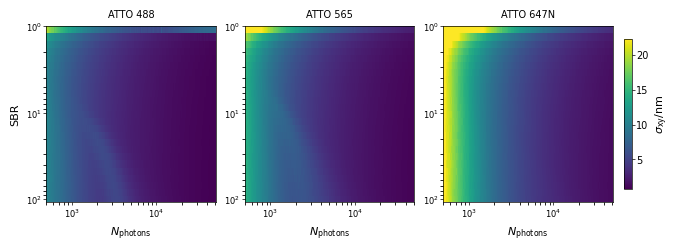

Saved sbr_surface_sigma_xy.svg


src.PlottingBase — INFO — Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/SBR/sbr_surface_sigma_colour.svg


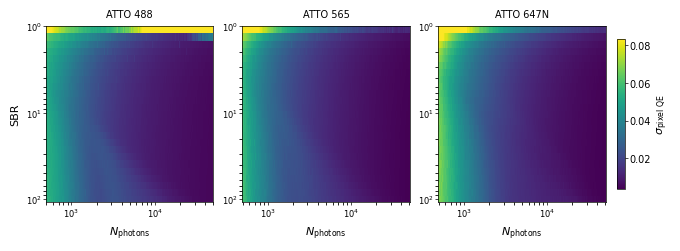

Saved sbr_surface_sigma_colour.svg


In [9]:
# ── Surface plots: rows = metric, cols = dye ──────────────────────────────────
metric_info = [
    ('sigma_xy',     r'$\sigma_{\rm xy}$/nm',          'viridis'),
    ('sigma_colour', r'$\sigma_{\rm pixel\ QE}$', 'viridis'),
]

for metric, cbar_lbl, cmap in metric_info:
    data_all = SBR_XR.sel(metric=metric).values   # (n_dye, n_sbr, n_ph)
    vmin = float(np.nanmin(data_all))
    vmax = float(np.nanpercentile(data_all, 99))
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    fig, axs = plt.subplots(
        nrows=1, ncols=len(dyes),
        figsize=(6.69, 2.4), squeeze=False,
    )
    for i_d, dye in enumerate(dyes):
        ax = axs[0, i_d]
        # Z shape: (n_sbr, n_ph); pcolormesh expects (Y, X)
        Z = SBR_XR.isel(dye=i_d).sel(metric=metric).values   # (n_sbr, n_ph)
        # rasterized=True embeds the mesh as a bitmap in the saved SVG instead of
        # per-quad vector polygons — avoids the thin gray/white seams that show
        # up between adjacent pcolormesh cells on vector export (anti-aliasing
        # gap between quad edges; see
        # https://stackoverflow.com/questions/30188011/matplotlib-svg-save-light-borders-around-contourf-levels).
        ax.pcolormesh(
            SBR_XR.coords['n_photons'].values,
            SBR_XR.coords['sbr'].values,
            Z,
            cmap=cmap, shading='auto', norm=norm,
            rasterized=True,
        )
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$N_{\rm photons}$', fontsize=fs+1)
        ax.set_ylabel('SBR' if i_d == 0 else '', fontsize=fs+1)
        ax.set_title(dye, fontsize=fs)
        ax.tick_params(labelsize=fs - 1)
        # Invert y so high SBR is at top (best conditions)
        ax.invert_yaxis()

    fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=axs,
        label=cbar_lbl,
        shrink=0.85, aspect=20, pad=0.02,
    )
    fname = f'sbr_surface_{metric}.svg'
    plotter.save_or_show(fig, save_path=os.path.join(figure_save_folder, fname), show=True, dpi=600)
    print(f'Saved {fname}')

## Ternary Plots — Case Studies

Compare three regimes that nominally differ in *kind* of limitation:

| Case | N photons | SBR | Limitation |
|------|-----------|-----|------------|
| A    | ~5 000    | 100 | — (reference) |
| B    | ~500      | 100 | signal-limited |
| C    | ~5 000    |   1 | background-limited |

If the spread in the colour simplex is similar for B and C, the two regimes
are physically equivalent for spectral discrimination purposes.

In [10]:
# ── Ternary helper: match PlottingBase.TernaryPlotMixin.create_ternary_plot ────
# Previously this drew its own hand-rolled triangle (_setup_ternary /
# _ternary_xy) on plain Cartesian axes, with G at the top vertex and no black
# background — inconsistent with every other ternary plot in the project. This
# now uses real mpltern ternary axes and the same convention/styling as
# PlottingBase.TernaryPlotMixin.create_ternary_plot (R=top, G=left, B=right;
# black interior; MultipleLocator gridlines at 0.2/0.1) — see also
# notebooks/figures/SI/Ternary_Plot_SingleMolecules.ipynb, which uses the same
# mpltern conventions. create_ternary_plot() itself only builds a standalone
# single-panel figure, so this helper applies the same styling to an existing
# axis in a multi-panel grid instead.
#
# Font sizes fixed to the project convention: tick labels 7pt, axis labels 8pt,
# annotations 6pt.

import mpltern  # noqa: F401 — registers the 'ternary' projection
from matplotlib.ticker import MultipleLocator

TICK_LABEL_SIZE = 7
AXIS_LABEL_SIZE = 8
ANNOTATION_SIZE = 6


def _setup_ternary(ax, black_background=True):
    """Style an existing mpltern ternary axis to match create_ternary_plot()."""
    if black_background:
        ax.set_facecolor('black')

    ax.set_tlabel('R', fontsize=AXIS_LABEL_SIZE)
    ax.set_llabel('G', fontsize=AXIS_LABEL_SIZE)
    ax.set_rlabel('B', fontsize=AXIS_LABEL_SIZE)

    for taxis in (ax.taxis, ax.laxis, ax.raxis):
        taxis.set_major_locator(MultipleLocator(0.2))
        taxis.set_minor_locator(MultipleLocator(0.1))
        taxis.set_tick_params(labelsize=TICK_LABEL_SIZE)
    ax.grid(lw=0.5, alpha=0.25, ls='--', which='both', axis='both')

    ax.set_tlim(0, 1)
    ax.set_llim(0, 1)
    ax.set_rlim(0, 1)


print('Ternary helper defined (mpltern, matches create_ternary_plot styling).')

Ternary helper defined (mpltern, matches create_ternary_plot styling).


/tmp/ipykernel_65313/782093798.py:93: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.35, hspace=0.3)
src.PlottingBase — INFO — Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/SBR/sbr_ternary_cases.svg


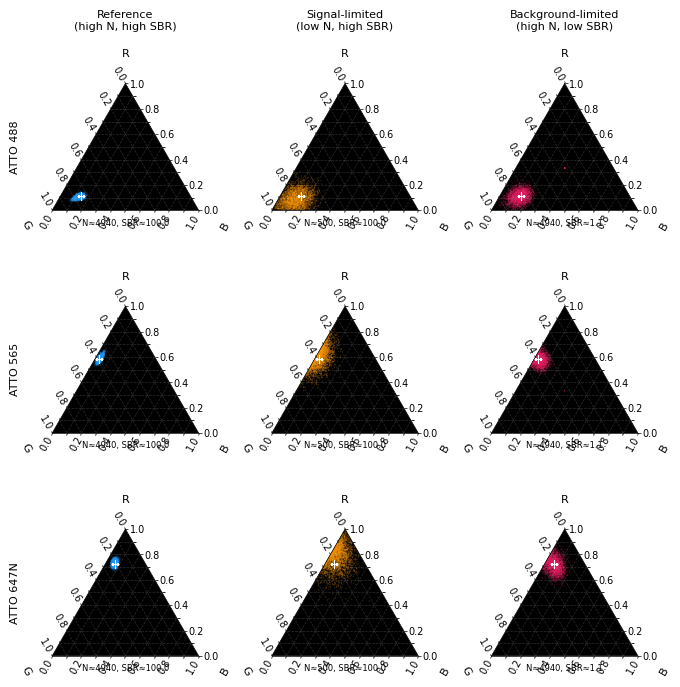

Ternary case study figure saved.


In [11]:
# ── Define case-study conditions ───────────────────────────────────────────────
cases = [
    ('Reference\n(high N, high SBR)', 5000, 100.0, '#2196F3'),
    ('Signal-limited\n(low N, high SBR)',  500, 100.0, '#FF9800'),
    ('Background-limited\n(high N, low SBR)', 5000,   1.1, '#E91E63'),
]
n_subsample = 3000   # max points per ternary panel

# ── Build grid: rows = dyes, cols = cases ─────────────────────────────────────
# Ternary axes via plotter.two_column_plot()'s subplot_kw passthrough, so the
# grid still goes through the shared figure-sizing/tick-styling convention
# instead of a bare plt.figure() + manual add_subplot() loop.
n_rows, n_cols = len(dyes), len(cases)
fig, axs = plotter.two_column_plot(
    nrows=n_rows, ncols=n_cols,
    height=n_rows * (6.69 / n_cols) + 0.3,
    subplot_kw={'projection': 'ternary'},
)
# two_column_plot() creates the figure with frameon=False (transparent figure
# background); restore an opaque white background so empty margins don't
# render as a gray/transparent box in some viewers.
fig.patch.set_facecolor('white')
fig.set_frameon(True)

for i_d, dye in enumerate(dyes):
    dye_str = dye.replace('/', '-')

    # True colour (B, G, R fractions) from any input_parameters file for this dye
    ip_any = sorted(glob.glob(str(save_folder / f'{sbr_flag(100.0)}*{dye_str}*input_parameters*.csv')))
    if ip_any:
        ip_row      = pd.read_csv(ip_any[0]).to_numpy()[0]
        colour_true = ip_row[-3:] / ip_row[-3:].sum()   # (B, G, R)
    else:
        colour_true = None

    for i_c, (case_label, n_ph_target, sbr_target, colour) in enumerate(cases):
        ax = axs[i_d, i_c]
        _setup_ternary(ax)

        # Snap to the closest value actually present in sbr_space (mirrors the
        # n_photon_space nearest-match below) so the flag always matches a
        # filename the sweep actually saved.
        sbr_closest = sbr_space[int(np.argmin(np.abs(sbr_space - sbr_target)))]
        flag        = sbr_flag(sbr_closest)
        h5_path     = save_folder / f'{flag}LM_method_{dye_str}_rawresults.h5'

        if not h5_path.exists():
            ax.text(0.5, 0.4, 'missing', ha='center', fontsize=ANNOTATION_SIZE,
                    transform=ax.transAxes, color='white')
        else:
            df_raw = pd.read_hdf(str(h5_path), key='data')

            # Find photon-level index closest to target
            k_closest = int(np.argmin(np.abs(n_photon_space - n_ph_target)))
            sub = df_raw[df_raw['photon_level'] == k_closest]
            filt = (
                (sub['s_x'].to_numpy() > 0) &
                (sub['s_y'].to_numpy() > 0) &
                (sub['xc'].to_numpy() > 0) &
                (sub['yc'].to_numpy() > 0)
            )
            sub_f = sub[filt]
            n_pts = min(len(sub_f), n_subsample)
            idx   = np.random.choice(len(sub_f), n_pts, replace=False)

            b_vals = sub_f['A_B'].to_numpy()[idx]
            g_vals = sub_f['A_G'].to_numpy()[idx]
            r_vals = sub_f['A_R'].to_numpy()[idx]

            # mpltern scatter(t, l, r): t=top=R, l=left=G, r=right=B
            ax.scatter(r_vals, g_vals, b_vals, s=0.8, alpha=0.25, color=colour,
                       edgecolors='None', rasterized=True)

            # True colour marker — white so it stays visible on the black background
            if colour_true is not None:
                b_true, g_true, r_true = colour_true
                ax.scatter([r_true], [g_true], [b_true], s=30, marker='+',
                           color='white', linewidths=0.8, zorder=5)

            n_actual = n_photon_space[k_closest]
            ax.text(0.5, -0.12,
                    f'N≈{n_actual:.0f}, SBR≈{sbr_closest:.1f}',
                    ha='center', fontsize=ANNOTATION_SIZE,
                    transform=ax.transAxes)

        if i_d == 0:
            ax.set_title(case_label, fontsize=AXIS_LABEL_SIZE, pad=14)
        if i_c == 0:
            ax.text(-0.22, 0.5, dye,
                    transform=ax.transAxes,
                    fontsize=AXIS_LABEL_SIZE, va='center', ha='right', rotation=90)

fig.subplots_adjust(wspace=0.35, hspace=0.3)
plotter.save_or_show(
    fig, save_path=os.path.join(figure_save_folder, 'sbr_ternary_cases.svg'), show=True, dpi=600
)
print('Ternary case study figure saved.')

## Precision along the SBR diagonal

Extract σ_xy and σ_colour along the diagonal where `N_photons × SBR = constant`
(i.e. fixed total detected photons but traded between signal and background).
Points along this diagonal should show similar precision, confirming the equivalence.

In [ ]:
# ── Iso-effective-photon curves ────────────────────────────────────────────────
# For each (N, SBR) pair, the effective detected photons contributing to
# localisation precision scales roughly as N/(1 + 1/SBR).  Plot precision
# vs this effective N so that signal-limited and background-limited cases
# collapse onto a single curve.

def effective_photons(n, sbr):
    """Approximation: photon-limited Fisher information with uniform background."""
    return n / (1 + 1 / sbr)

N_grid, SBR_grid = np.meshgrid(n_photon_space, sbr_space)   # (n_sbr, n_ph)
N_eff = effective_photons(N_grid, SBR_grid)

fs = plotter.config.font_size
fig, axs = plt.subplots(1, 2, figsize=(6.69, 2.6), squeeze=True)

for ax, metric, ylabel in [
    (axs[0], 'sigma_xy',     r'$\sigma_{xy}$ / nm'),
    (axs[1], 'sigma_colour', r'$\sigma_{\rm colour}$ (a.u.)'),
]:
    for i_d, (dye, ls) in enumerate(zip(dyes, ['-', '--', ':'])):
        for i_s, (sbr, alpha) in enumerate(zip(sbr_space, np.linspace(1.0, 0.35, len(sbr_space)))):
            y = SBR_XR.isel(dye=i_d, sbr=i_s).sel(metric=metric).values
            x = N_eff[i_s, :]
            valid = ~np.isnan(y)
            label = dye if i_s == 0 else None
            ax.plot(x[valid], y[valid], ls=ls, lw=0.9,
                    color=f'C{i_d}', alpha=alpha, label=label)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'Effective photons $N/(1+1/\mathrm{SBR})$', fontsize=fs)
    ax.set_ylabel(ylabel, fontsize=fs)
    ax.tick_params(labelsize=fs - 1)

axs[0].legend(fontsize=fs - 2, framealpha=0.7)
fig.suptitle(
    'Each curve = one SBR level (solid→dashed→dotted per dye; opacity decreases with SBR)',
    fontsize=fs - 2,
)
fig.tight_layout(pad=0.4)
plotter.save_or_show(
    fig, save_path=str(save_folder / 'sbr_effective_photons_collapse.svg'), show=True
)
print('Effective-photon collapse figure saved.')